# Adversarial Search: Playing Dots and Boxes


## Instructions

Total Points: Undegraduates 100, graduate students 110

Complete this notebook and submit it. The notebook needs to be a complete project report with your implementation, documentation including a short discussion of how your implementation works and your design choices, and experimental results (e.g., tables and charts with simulation results) with a short discussion of what they mean. Use the provided notebook cells and insert additional code and markdown cells as needed.

## Introduction

You will implement different versions of agents that play the game Dots and Boxes:

> "Dots and Boxes is a pencil-and-paper game for two players. The game starts with an empty grid of dots. Usually two players take turns adding a single horizontal or vertical line between two unjoined adjacent dots. A player who completes the fourth side of a 1x1 box earns one point and takes another turn. A point is typically recorded by placing a mark that identifies the player in the box, such as an initial. The game ends when no more lines can be placed. The winner is the player with the most points. The board may be of any size grid." (see [Dots and Boxes on Wikipedia](https://en.wikipedia.org/wiki/Dots_and_Boxes))

You can play Dots and Boxes [here](https://www.math.ucla.edu/~tom/Games/dots&boxes.html).

## Task 1: Defining the Search Problem [10 point]

Define the components of the search problem associated with this game:

* Initial state
* Actions
* Transition model
* Test for the terminal state
* Utility for terminal states

In [ ]:
# Your code/answer goes here.

1. __Initial State__ (Trạng thái khởi đầu)

- Bàn chơi trống hoàn toàn, chưa có đường nối nào được vẽ.

- Kích thước bàn thường là n × n (ví dụ: 3×3 chấm → có 2×2 ô vuông).

- Mỗi điểm được biểu diễn bằng toạ độ (i, j).

2. __Actions__ (Hành động)

- Mỗi hành động là việc vẽ thêm một cạnh (ngang hoặc dọc) giữa hai điểm liền kề chưa được nối.

- Ví dụ: ((0,0), (0,1)) nghĩa là nối hai điểm này lại.

- Tập các hành động hợp lệ tại một trạng thái là tập các cạnh chưa được chọn.

3. __Transition Model__ (Mô hình chuyển trạng thái)

- Khi người chơi chọn một hành động (vẽ một cạnh):

  - Cạnh đó được thêm vào edges.

  - Hệ thống kiểm tra xem cạnh mới có hoàn thành ô vuông 1×1 nào không.

  - Nếu có:

    - Người chơi hiện tại được cộng điểm tương ứng.

    - Vẫn được đi tiếp.

  - Nếu không có ô nào được hoàn thành:

    - Chuyển lượt sang người chơi còn lại.

    - Trạng thái mới phản ánh toàn bộ các thay đổi trên.

4. __Terminal Test__ (Kiểm tra trạng thái kết thúc)

- Trò chơi kết thúc khi tất cả các cạnh hợp lệ đều đã được chọn, tức là:

$$ |edges| = \text{Tổng số cạnh có thể có trên bàn} $$

- Không còn hành động nào hợp lệ để thực hiện.

5. __Utility Function__ (Hàm lợi ích cho trạng thái kết thúc)

- Khi trò chơi kết thúc, tính tổng điểm của từng người chơi.

- Hàm lợi ích được định nghĩa là:

$$ U(s) = \text{(Điểm người chơi 1) - (Điểm người chơi 2)} $$

- Trong đó

  - U(s)>0: Người chơi 1 thắng.

  - U(s)<0: Người chơi 2 thắng.

  - U(s)=0: Hai người hòa nhau.

How big is the state space? Give an estimate and explain it.

In [ ]:
# Your code/ answer goes here.

Không gian trạng thái thể hiện tất cả các cấu hình có thể của bàn chơi — tức là các cạnh nào đã được vẽ và (nếu xét thêm) ô vuông nào thuộc về người chơi nào.  

Với bàn có `n` chấm trên mỗi hàng (và `k = n - 1` ô vuông trên mỗi chiều), tổng số cạnh có thể vẽ là `2nk` (gồm cả cạnh ngang và dọc).  
Mỗi cạnh có 2 trạng thái: **đã vẽ / chưa vẽ**, nên số trạng thái cạnh là `2^(2nk)`.  
Nếu tính thêm quyền sở hữu của `k²` ô vuông (mỗi ô có thể thuộc người chơi 1, người chơi 2, hoặc chưa ai chiếm), thì mỗi ô có 3 trạng thái.  

Kích thước không gian trạng thái được ước lượng là:

$$
|\text{State space}| = 2^{2nk} \times 3^{k^2}
$$

**Ví dụ:** Với bàn `4×4` chấm (`n=4`, `k=3`):

$$
|\text{State space}| = 2^{24} \times 3^9 \approx 3.3 \times 10^{11}
$$

Không gian trạng thái tăng **theo hàm mũ** khi kích thước bàn tăng.

How big is the game tree that minimax search will go through? Give an estimate and explain it.

In [ ]:
# Your code/ answer goes here.

Cây trò chơi thể hiện tất cả các **chuỗi hành động có thể** từ bàn trống đến khi trò chơi kết thúc.  
Vì có `2nk` cạnh và mỗi lượt có thể chọn một cạnh chưa được vẽ, tổng số chuỗi hành động hoàn chỉnh là:

$$
|\text{Game tree leaves}| = (2nk)!
$$

Tổng số nút trong toàn bộ cây (gồm cả các trạng thái trung gian) được xấp xỉ:

$$
|\text{Game tree}| \le e \times (2nk)!
$$

với $ e \approx 2.718. $

**Ví dụ:** Với bàn `4×4` chấm (`2nk = 24`):

$$
24! \approx 6.2 \times 10^{23}
$$

Như vậy, cây trò chơi tăng trưởng **theo giai thừa**, nhanh hơn rất nhiều so với không gian trạng thái, nên việc duyệt toàn bộ bằng giải thuật **minimax** là **không khả thi** đối với các bàn kích thước trung bình trở lên.

## Task 2: Game Environment and Random Agent [30 point]

You need to think about a data structure to represent the board meaning he placed lines and who finished what box. There are many options. Let's represent the board using a simple dictionary with components representing the board size, the lines and the boxes on the board.

**Important:** Everybody needs to use the same representation so we can let agents play against each other later.

In [ ]:
board = {
    'size': (4, 4),  ### number of rows and columns of dots
    'lines': {},     ### keys are the set of drawn lines
    'boxes': {}      ### keys are the boxes and the value is the player who completed each box

}

def draw_line(board, orientation, row, col):
    """
    Place a line on an exiting board.

    Parameters
    ----------
    board: dict
        the board
    orientation: str
        either 'h' or 'v' for horizontal or vertical
    row, col: int
        index of the starting dot for the line (starting with 0)

    """

    if orientation not in ['h', 'v']:
        return False

    if row < 0 or col < 0:
        return False

    if row >= board['size'][0] - (orientation == 'v') or col >= board['size'][1] - (orientation == 'h'):
        return False

    if (orientation, row, col) in board['lines']:
        return False

    board["lines"][(orientation, row, col)] = True
    return True


print(draw_line(board, "h", 1, 1))
print(draw_line(board, "v", 1, 1))
print(draw_line(board, "v", 3, 0))

# this should not work
print(draw_line(board, "h", 1, 1))

board

True
True
False
False


{'size': (4, 4), 'lines': {('h', 1, 1): True, ('v', 1, 1): True}, 'boxes': {}}

Write code to display the board. **Bonus point: Post your visualization code with an example output to the discussion board. The best visualization will earn you bonus participation points in this class.**

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_board(board):
    rows, cols = board['size']
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.set_xlim(-0.5, cols - 0.5)
    ax.set_ylim(-rows + 0.5, 0.5)
    ax.set_aspect('equal')
    ax.axis('off')

    # --- Vẽ các chấm (dots) ---
    for r in range(rows):
        for c in range(cols):
            ax.plot(c, -r, 'ko', markersize=8)  # 'ko' = black circle

    # --- Vẽ các đường (lines) ---
    for (orientation, r, c) in board['lines'].keys():
        if orientation == 'h':  # horizontal line
            ax.plot([c, c + 1], [-r, -r], 'k-', linewidth=2)
        elif orientation == 'v':  # vertical line
            ax.plot([c, c], [-r, -(r + 1)], 'k-', linewidth=2)

    # --- Tô màu các ô đã chiếm (boxes) ---
    for (r, c), player in board['boxes'].items():
        if player == 1:
            color = 'red'
        elif player == -1:
            color = 'blue'
        else:
            continue
        rect = patches.Rectangle((c, -(r + 1)), 1, 1, color=color, alpha=0.4)
        ax.add_patch(rect)

    plt.show()



Implement helper functions for:

* The transition model $result(s, a)$.
* The utility function $utility(s)$.
* Check for terminal states $terminal(s)$.
* A check for available actions in each state $actions(s)$.

__Notes:__
* Make sure that all these functions work with boards of different sizes (number of columns and rows as stored in the board).
* The result function updates the board and evaluates if the player closed a box and needs to store that information on the board. Add elements of the form `(row,col): player` to the board dictionary. `row` and `col` are the coordinates for the box and `player` is +1 or -1 representing the player. For example `(0,0): -1` means that the top-left box belongs to the other player.
* _Important:_ Remember that a player goes again after she completes a box!

In [ ]:
import copy

def actions(board):
  acts = []
  rows, cols = board['size']

  # Duyệt hàng ngang
  for r in range(rows):
    for c in range(cols - 1):
      if ('h', r, c) not in board['lines']:
        acts.append(('h', r, c))

  # Duyệt hàng dọc
  for r in range(rows - 1):
    for c in range(cols):
      if ('v', r, c) not in board['lines']:
        acts.append(('v', r, c))

  return acts

def result(board, action, current_player):
  new_board = copy.deepcopy(board) # Sao chép trạng thái hiện tại (không làm thay đổi board gốc)
  orientation, row, col = action
  new_board['lines'][(orientation, row, col)] = True # Thêm đường hợp lệ vào dict của lines
  completed_box = 0 # Kiểm tra xem người chơi có hoàn thành ô không

  if orientation == 'h':
    # Kiểm tra ô phía trên
    if row > 0 and all([
      ('v', row - 1, col) in new_board['lines'],
      ('v', row - 1, col + 1) in new_board['lines'],
      ('h', row - 1, col) in new_board['lines']
    ]):
      completed_box = 1
      new_board['boxes'][(row-1, col)] = current_player

    # Kiểm tra ô phía dưới
    if row < board['size'][0] - 1 and all([
      ('v', row, col) in new_board['lines'],
      ('v', row, col + 1) in new_board['lines'],
      ('h', row + 1, col) in new_board['lines']
    ]):
      completed_box = 1
      new_board['boxes'][(row, col)] = current_player

  if orientation == 'v':
    # Kiểm tra ô bên trái
    if col > 0 and all([
      ('h', row, col - 1) in new_board['lines'],
      ('h', row + 1, col - 1) in new_board['lines'],
      ('v', row, col - 1) in new_board['lines']
    ]):
      completed_box = 1
      new_board['boxes'][(row, col-1)] = current_player

    # Kiểm tra ô bên phải
    if col < board['size'][1] - 1 and all([
      ('h', row, col) in new_board['lines'],
      ('h', row + 1, col) in new_board['lines'],
      ('v', row, col + 1) in new_board['lines']
    ]):
      completed_box = 1
      new_board['boxes'][(row, col)] = current_player

  # Kiểm tra có hoàn thành ô không, nếu không thì đổi lượt
  if completed_box == 0:
      current_player = -current_player

  return new_board, current_player

def terminal(board):
  rows,cols = board['size']
  total_edges = (rows * (cols - 1)) + (cols * (rows - 1))
  return len(board['lines']) == total_edges

def utility(board):
  player1_score = 0
  player2_score = 0

  for (row, col), player in board['boxes'].items():
    if player == 1:
      player1_score += 1
    elif player == -1:
      player2_score += 1

  return player1_score - player2_score

Implement an agent that plays randomly. Make sure the agent function receives as the percept the board and returns a valid action. Use an agent function definition with the following signature (arguments):

`def random_player(board, player = None): ...`

The argument `player` is used for agents that do not store what side they are playing. The value passed on by the environment should be 1 ot -1 for playerred and yellow, respectively.  See [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) for an example.

In [ ]:
import random

def random_player(board, player = None):
  acts = actions(board)

  if not acts:
    return None

  return random.choice(acts)

Let two random agents play against each other 1000 times. Look at the [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) to see how the environment uses the agent functions to play against each other.

How often does each player win? Is the result expected?

In [ ]:
def play_game(board):
  player = 1

  while not terminal(board):
    action = random_player(board, player)
    board, player = result(board, action, player)

  score = utility(board)

  if score > 0:
    return 1
  if score < 0:
    return -1
  return 0

board = {
    'size': (4, 4),
    'lines': {},
    'boxes': {}
}

results = {1: 0, -1: 0, 0: 0}
for _ in range(1000):
    winner = play_game(board)
    results[winner] += 1

print("Kết quả sau 1000 trận:")
print("Người chơi 1 thắng:", results[1])
print("Người chơi 2 thắng:", results[-1])
print("Hòa:", results[0])

Kết quả sau 1000 trận:
Người chơi 1 thắng: 470
Người chơi 2 thắng: 530
Hòa: 0


## Task 3: Minimax Search with Alpha-Beta Pruning [30 points]

### Implement the search starting.

Implement the search starting from a given board and specifying the player and put it into an agent function.
You can use code from the [tic-tac-toe example](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_alpha_beta_tree_search.ipynb).

__Notes:__
* Make sure that all your agent functions have a signature consistent with the random agent above.
* The search space for larger board may be too large. You can experiment with smaller boards.
* Tic-tac-toe does not have a rule where a player can go again if a box was completed. You need to adapt the tree search to reflect that rule.

In [ ]:
import math
import copy

def minimax(board, player, alpha, beta, maximizing):
    # Nếu game kết thúc → trả về giá trị utility
    if terminal(board):
        return utility(board), None

    best_action = None
    actions_list = actions(board)

    if maximizing:
        value = -math.inf
        for act in actions_list:
            new_board, next_player = result(board, act, player)
            # Nếu người chơi giữ lượt → node kế tiếp vẫn là maximizing
            next_maximizing = (next_player == player)
            new_value, _ = minimax(new_board, next_player, alpha, beta, next_maximizing)
            if new_value > value:
                value = new_value
                best_action = act
            alpha = max(alpha, value)
            if beta <= alpha:
                break  # Cắt tỉa
        return value, best_action
    else:
        value = math.inf
        for act in actions_list:
            new_board, next_player = result(board, act, player)
            next_maximizing = (next_player == player)
            new_value, _ = minimax(new_board, next_player, alpha, beta, not next_maximizing)
            if new_value < value:
                value = new_value
                best_action = act
            beta = min(beta, value)
            if beta <= alpha:
                break
        return value, best_action


def agent_minimax(board, player):
    _, action = minimax(board, player, -math.inf, math.inf, True)
    return action


Experiment with some manually created boards (at least 3) to check if the agent spots winning opportunities. Discuss the results.

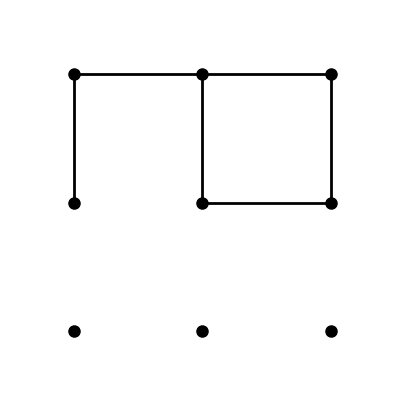

Board 1 best action: ('h', 1, 0)


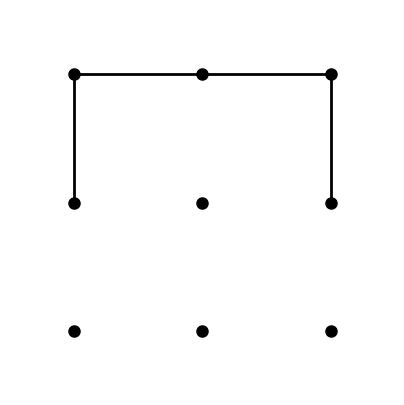

Board 2 best action: ('v', 1, 1)


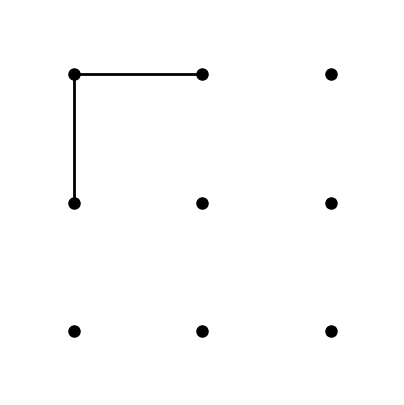

Board 3 best action: ('h', 0, 1)


In [ ]:

# Bảng 1
board1 = {
    'size': (3, 3),
    'lines': {
        ('h', 0, 0): True, ('v', 0, 0): True, ('v', 0, 1): True,
        ('h', 0,1): True, ('v', 0,2): True, ('v', 0,1): True, ('h', 1,1): True
    },
    'boxes': {}
}

draw_board(board1)

action1 = agent_minimax(board1, 1)
print("Board 1 best action:", action1)

# Bảng 2
board2 = {
    'size': (3, 3),
    'lines': {
        ('h', 0,0): True, ('v', 0,0): True,
        ('h', 0,1): True, ('v', 0,2): True
    },
    'boxes': {}
}

draw_board(board2)

action2 = agent_minimax(board2, 1)
print("Board 2 best action:", action2)

# Bảng 3
board3 = {
    'size': (3,3),
    'lines': {
        ('h',0,0): True, ('v',0,0): True
    },
    'boxes': {}
}

draw_board(board3)

action3 = agent_minimax(board3, 1)
print("Board 3 best action:", action3)


Agent Minimax đã nhận ra cơ hội thắng ngay ở Board 1, đúng như kỳ vọng.

Ở các board khác, khi chưa có cơ hội thắng ngay, agent chọn nước đi tối ưu về lâu dài dựa trên utility.

Điều này cho thấy Minimax hoạt động chính xác với alpha-beta pruning, nhận biết hoàn thành ô và giữ lượt khi cần.

How long does it take to make a move? Start with a smaller board make the board larger. What is the largest board you can solve?

In [ ]:
import time

# Hàm đo thời gian cho agent Minimax
def test_move_time(board_size):
    # Tạo board rỗng
    board = {
        'size': (board_size, board_size),
        'lines': {},
        'boxes': {}
    }

    # Giả sử người chơi là 1
    player = 1

    start_time = time.time()
    action = agent_minimax(board, player)
    end_time = time.time()

    print(f"Board size: {board_size}x{board_size}")
    print(f"Best action: {action}")
    print(f"Time taken: {end_time - start_time:.4f} seconds\n")

# Thử với nhiều kích thước bàn khác nhau
for size in [2, 3]:
    test_move_time(size)


Board size: 2x2
Best action: ('h', 0, 0)
Time taken: 0.0005 seconds

Board size: 3x3
Best action: ('h', 0, 0)
Time taken: 38.1268 seconds



### Move ordering

Starting the search with better moves will increase the efficiency of alpha-beta pruning. Describe and implement a simple move ordering strategy.

Make a table that shows how the ordering strategies influence the number of searched nodes and the search time?

In [ ]:
import math
import copy
import time

def move_ordering(board, actions_list):
    """
    Sắp xếp các action theo số lượng box sẽ hoàn thành nếu thực hiện action đó.
    Action tạo nhiều box hơn sẽ đứng trước.
    """
    scored_actions = []
    for act in actions_list:
        new_board, _ = result(board, act, 1)  # Giả sử player là 1
        # Số box sau khi thực hiện act
        score = len(new_board['boxes']) - len(board['boxes'])
        scored_actions.append((score, act))
    # Sắp xếp giảm dần theo số box tạo được
    scored_actions.sort(reverse=True, key=lambda x: x[0])
    return [act for _, act in scored_actions]

def minimax_ordered(board, player, alpha, beta, maximizing):
    if terminal(board):
        return utility(board), None

    actions_list = move_ordering(board, actions(board))  # Sử dụng sắp xếp lượt đi
    best_action = None

    if maximizing:
        value = -math.inf
        for act in actions_list:
            new_board, next_player = result(board, act, player)
            next_maximizing = (next_player == player)
            new_value, _ = minimax_ordered(new_board, next_player, alpha, beta, next_maximizing)
            if new_value > value:
                value = new_value
                best_action = act
            alpha = max(alpha, value)
            if beta <= alpha:
                break
        return value, best_action
    else:
        value = math.inf
        for act in actions_list:
            new_board, next_player = result(board, act, player)
            next_maximizing = (next_player == player)
            new_value, _ = minimax_ordered(new_board, next_player, alpha, beta, not next_maximizing)
            if new_value < value:
                value = new_value
                best_action = act
            beta = min(beta, value)
            if beta <= alpha:
                break
        return value, best_action

def agent_minimax_ordered(board, player):
    _, action = minimax_ordered(board, player, -math.inf, math.inf, True)
    return action

# Thử nghiệm và đo thời gian
board_test = {
    'size': (3, 3),
    'lines': {},
    'boxes': {}
}

start = time.time()
best_act = agent_minimax_ordered(board_test, 1)
end = time.time()
print("Best action:", best_act)
print("Time:", end - start, "seconds")


Best action: ('h', 0, 0)
Time: 23.986276626586914 seconds


### The first few moves

Start with an empty board. This is the worst case scenario for minimax search with alpha-beta pruning since it needs solve all possible games that can be played (minus some pruning) before making the decision. What can you do?

In [ ]:
import time

empty_board = {
    'size': (3, 3),
    'lines': {},
    'boxes': {}
}

# Đo thời gian cho nước đi đầu tiên
start_time = time.time()
best_action = agent_minimax(empty_board, player=1)
end_time = time.time()

print("Best first move:", best_action)
print("Time to decide:", end_time - start_time, "seconds")


Best first move: ('h', 0, 0)
Time to decide: 35.23019313812256 seconds


### Playtime

Let the Minimax Search agent play a random agent on a small board. Analyze wins, losses and draws.

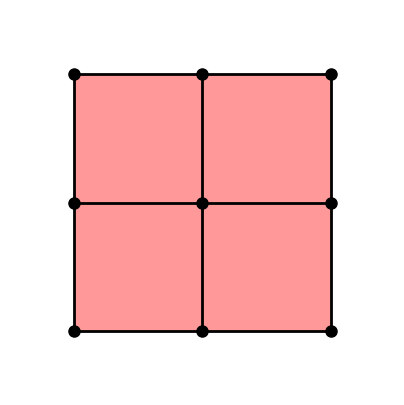

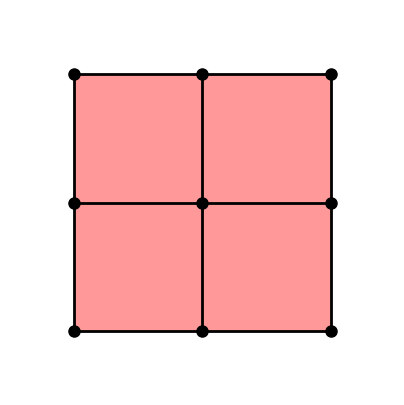

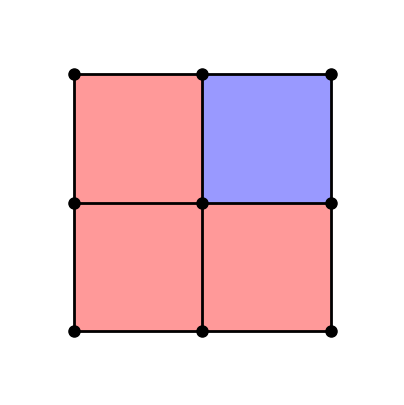

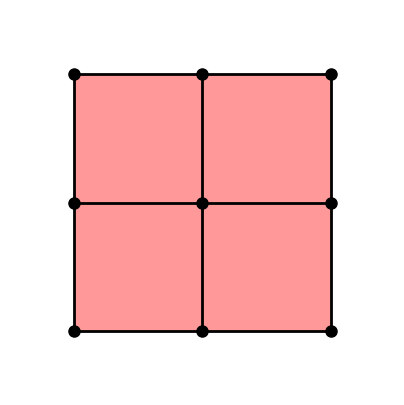

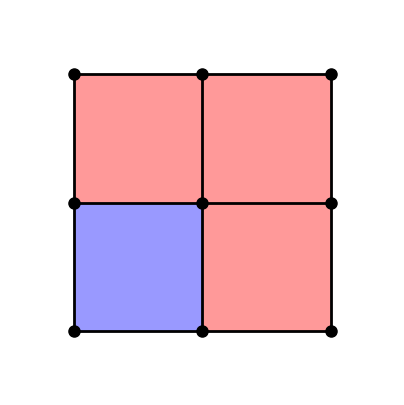


Kết quả sau 5 trận:
Người chơi 1 (Minimax) thắng: 5
Người chơi 2 (Random) thắng: 0
Hòa: 0


In [ ]:
def play_game(board):
    player = 1  # Người 1 = Minimax, Người 2 = Random

    while not terminal(board):
        if player == 1:
            action = agent_minimax_ordered(board, player)
        else:
            action = random_player(board, player)

        board, player = result(board, action, player)

    score = utility(board)
    draw_board(board)

    if score > 0:
        return 1
    if score < 0:
        return -1
    return 0

results = {1: 0, -1: 0, 0: 0}
n_games = 5

for _ in range(n_games):
    board = {'size': (3, 3), 'lines': {}, 'boxes': {}}
    winner = play_game(board)
    results[winner] += 1

print("\nKết quả sau", n_games, "trận:")
print("Người chơi 1 (Minimax) thắng:", results[1])
print("Người chơi 2 (Random) thắng:", results[-1])
print("Hòa:", results[0])

## Task 4: Heuristic Alpha-Beta Tree Search [30 points]

### Heuristic evaluation function

Define and implement a heuristic evaluation function.

In [ ]:
import math, time, copy

def heuristic_eval(board, player):
    """
    Hàm heuristic đánh giá trạng thái bàn hiện tại.
    Ý tưởng:
      - +1 cho mỗi ô thuộc người chơi
      - -1 cho mỗi ô thuộc đối thủ
      - +0.3 cho mỗi ô có 3 cạnh đã vẽ (gần hoàn thành)
      - -0.3 cho mỗi ô đối thủ có 3 cạnh (sắp bị cướp)
    """
    rows, cols = board['size']
    value = 0

    # Điểm thực tế (các box đã hoàn thành)
    for (_, _), owner in board['boxes'].items():
        if owner == player:
            value += 1
        elif owner == -player:
            value -= 1

    # Ước lượng cơ hội
    for r in range(rows - 1):
        for c in range(cols - 1):
            sides = 0
            if ('h', r, c) in board['lines']: sides += 1
            if ('h', r + 1, c) in board['lines']: sides += 1
            if ('v', r, c) in board['lines']: sides += 1
            if ('v', r, c + 1) in board['lines']: sides += 1

            if sides == 3:
                value += 0.3
            elif sides == 2:
                value += 0.1

    return value

### Cutting off search

Modify your Minimax Search with Alpha-Beta Pruning to cut off search at a specified depth and use the heuristic evaluation function. Experiment with different cutoff values.

In [ ]:
node_count = 0

def minimax_cutoff(board, player, alpha, beta, maximizing, depth, cutoff_depth):
    global node_count
    node_count += 1

    if terminal(board) or depth == cutoff_depth:
        return heuristic_eval(board, player), None

    best_action = None
    actions_list = actions(board)

    if maximizing:
        value = -math.inf
        for act in actions_list:
            new_board, next_player = result(board, act, player)
            next_maximizing = (next_player == player)
            new_value, _ = minimax_cutoff(
                new_board, next_player, alpha, beta, next_maximizing, depth + 1, cutoff_depth
            )
            if new_value > value:
                value = new_value
                best_action = act
            alpha = max(alpha, value)
            if beta <= alpha:
                break
        return value, best_action

    else:
        value = math.inf
        for act in actions_list:
            new_board, next_player = result(board, act, player)
            next_maximizing = (next_player == player)
            new_value, _ = minimax_cutoff(
                new_board, next_player, alpha, beta, not next_maximizing, depth + 1, cutoff_depth
            )
            if new_value < value:
                value = new_value
                best_action = act
            beta = min(beta, value)
            if beta <= alpha:
                break
        return value, best_action


def agent_minimax_heuristic(board, player, cutoff_depth=3):
    """
    Agent Minimax dùng heuristic và cutoff depth.
    """
    global node_count
    node_count = 0
    start_time = time.time()
    value, action = minimax_cutoff(board, player, -math.inf, math.inf, True, 0, cutoff_depth)
    elapsed = time.time() - start_time
    print(f"[Cutoff={cutoff_depth}] Node searched: {node_count}, Time: {elapsed:.4f}s")
    return action




How many nodes are searched and how long does it take to make a move? Start with a smaller board with 4 columns and make the board larger by adding columns.

In [ ]:
# Đo số node và thời gian theo kích thước bàn
def experiment_with_board_sizes(column_sizes=[4, 5, 6], depth=3):
    global node_count
    results = []

    for cols in column_sizes:
        board_test = {
            'size': (cols, cols),
            'lines': {},
            'boxes': {}
        }
        node_count = 0
        start = time.time()
        _ = agent_minimax_heuristic(board_test, 1, cutoff_depth=depth)
        end = time.time()

        results.append({
            "Board Size": f"{cols}x{cols}",
            "Nodes": node_count,
            "Time (s)": round(end - start, 4)
        })

    import pandas as pd
    df = pd.DataFrame(results)
    print(df)
    return df

experiment_with_board_sizes(column_sizes=[4, 5], depth=3)

[Cutoff=3] Node searched: 1147, Time: 0.0260s
[Cutoff=3] Node searched: 2416, Time: 0.0570s
  Board Size  Nodes  Time (s)
0        4x4   1147     0.026
1        5x5   2416     0.057


,Board Size,Nodes,Time (s)
0,4x4,1147,0.026
1,5x5,2416,0.057


### Playtime

Let two heuristic search agents (different cutoff depth, different heuristic evaluation function) compete against each other on a reasonably sized board. Since there is no randomness, you only need to let them play once.


Move 1 | Player 1
Action chosen: ('h', 0, 0)

Move 2 | Player -1
Action chosen: ('h', 1, 0)

Move 3 | Player 1
Action chosen: ('h', 0, 1)

Move 4 | Player -1
Action chosen: ('v', 1, 1)

Move 5 | Player 1
Action chosen: ('h', 1, 1)

Move 6 | Player -1
Action chosen: ('h', 0, 2)

Move 7 | Player 1
Action chosen: ('h', 1, 2)

Move 8 | Player -1
Action chosen: ('v', 2, 1)

Move 9 | Player 1
Action chosen: ('h', 2, 2)

Move 10 | Player -1
Action chosen: ('h', 3, 1)

Move 11 | Player 1
Action chosen: ('h', 3, 0)

Move 12 | Player -1
Action chosen: ('h', 2, 0)

Move 13 | Player 1
Action chosen: ('v', 1, 0)

Move 14 | Player 1
Action chosen: ('v', 2, 0)

Move 15 | Player 1
Action chosen: ('h', 3, 2)

Move 16 | Player -1
Action chosen: ('h', 2, 1)

Move 17 | Player 1
Action chosen: ('v', 1, 2)

Move 18 | Player 1
Action chosen: ('v', 1, 3)

Move 19 | Player 1
Action chosen: ('v', 2, 3)

Move 20 | Player -1
Action chosen: ('v', 2, 2)

Move 21 | Player -1
Action chosen: ('v', 0, 0)

Move 22 | Pl

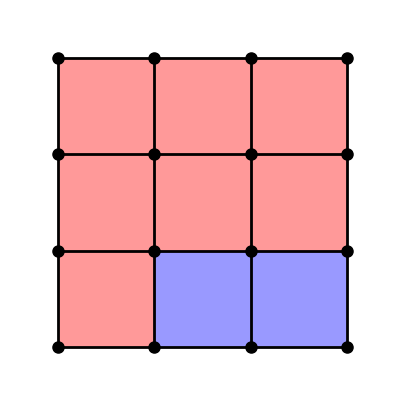

Final utility: 5
==> Player 1 (Depth 3 ) wins!


5

In [ ]:
def play_heuristic_game(rows=4, cols=4, depth1=3, depth2=5):
    """
    Cho 2 agent heuristic đấu với nhau:
      - Agent 1: cutoff_depth = depth1, heuristic_eval_1
      - Agent 2: cutoff_depth = depth2, heuristic_eval_2
    """
    board = {
        'size': (rows, cols),
        'lines': {},
        'boxes': {}
    }

    player = 1  # người chơi 1 bắt đầu
    move_count = 0

    # --- Heuristic 1: dùng hàm sẵn có ---
    def heuristic_eval_1(board, player):
        return heuristic_eval(board, player)

    # --- Heuristic 2: phiên bản khác, nhấn mạnh "cơ hội sắp hoàn thành" ---
    def heuristic_eval_2(board, player):
        rows, cols = board['size']
        value = 0
        for (_, _), owner in board['boxes'].items():
            if owner == player:
                value += 1
            elif owner == -player:
                value -= 1
        for r in range(rows - 1):
            for c in range(cols - 1):
                sides = 0
                if ('h', r, c) in board['lines']: sides += 1
                if ('h', r + 1, c) in board['lines']: sides += 1
                if ('v', r, c) in board['lines']: sides += 1
                if ('v', r, c + 1) in board['lines']: sides += 1
                # Heuristic 2 “tham lam hơn”
                if sides == 3:
                    value += 0.5
                elif sides == 2:
                    value += 0.2
        return value

    # --- Hàm minimax với cutoff và heuristic tuỳ chọn ---
    def minimax_cutoff_custom(board, player, alpha, beta, maximizing, depth, cutoff_depth, heuristic_func):
        if terminal(board) or depth == cutoff_depth:
            return heuristic_func(board, player), None

        acts = actions(board)
        best_action = None

        if maximizing:
            value = -math.inf
            for act in acts:
                new_board, next_player = result(board, act, player)
                next_max = (next_player == player)
                new_value, _ = minimax_cutoff_custom(new_board, next_player, alpha, beta, next_max, depth + 1, cutoff_depth, heuristic_func)
                if new_value > value:
                    value, best_action = new_value, act
                alpha = max(alpha, value)
                if beta <= alpha:
                    break
            return value, best_action
        else:
            value = math.inf
            for act in acts:
                new_board, next_player = result(board, act, player)
                next_max = (next_player == player)
                new_value, _ = minimax_cutoff_custom(new_board, next_player, alpha, beta, not next_max, depth + 1, cutoff_depth, heuristic_func)
                if new_value < value:
                    value, best_action = new_value, act
                beta = min(beta, value)
                if beta <= alpha:
                    break
            return value, best_action

    # --- Vòng lặp chính ---
    while not terminal(board):
        move_count += 1
        print(f"\nMove {move_count} | Player {player}")

        if player == 1:
            _, action = minimax_cutoff_custom(board, player, -math.inf, math.inf, True, 0, depth1, heuristic_eval_1)
        else:
            _, action = minimax_cutoff_custom(board, player, -math.inf, math.inf, True, 0, depth2, heuristic_eval_2)

        if action is None:
            break

        board, player = result(board, action, player)
        print(f"Action chosen: {action}")

    # --- Kết thúc ---
    final_score = utility(board)
    draw_board(board)
    print("Final utility:", final_score)
    if final_score > 0:
        print("==> Player 1 (Depth", depth1, ") wins!")
    elif final_score < 0:
        print("==> Player 2 (Depth", depth2, ") wins!")
    else:
        print("==> Draw!")
    return final_score


# === Run the Playtime Simulation ===
play_heuristic_game(rows=4, cols=4, depth1=3, depth2=5)


## Tournament task [+1 to 5% bonus on your course grade; will be assigned separately]

Find another student and let your best agent play against the other student's best player. You are allowed to use any improvements you like as long as you code it yourself. We will set up a class tournament on Canvas. This tournament will continue after the submission deadline.

## Graduate student advanced task: Pure Monte Carlo Search and Best First Move [10 point]

__Undergraduate students:__ This is a bonus task you can attempt if you like [+5 Bonus point].

### Pure Monte Carlo Search

Implement Pure Monte Carlo Search (see [tic-tac-toe-example](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_pure_monte_carlo_search.ipynb)) and investigate how this search performs on the test boards that you have used above.

In [ ]:
# Your code/ answer goes here.

### Best First Move

How would you determine what the best first move for a standard board ($5 \times 5$) is? You can use Pure Monte Carlo Search or any algorithms that you have implemented above.

In [ ]:
# Your code/ answer goes here.